<a href="https://colab.research.google.com/github/mihirmitra11-sys/AstroRestore-UNet/blob/main/Crater_identification_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Phase 1 — Data

In [2]:
# ============================================================
# MASTER SETUP — run this first after any session restart
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# --- Catalog ---
np.random.seed(42)
n = 78000
diameters = np.random.pareto(2.5, n) * 4 + 5.0
diameters = diameters[diameters < 1200][:n]
df = pd.DataFrame({
    'Lat':        np.random.uniform(-90, 90, len(diameters)),
    'Long':       np.random.uniform(0, 360, len(diameters)),
    'Diam_km':    diameters,
    'Morphology': np.random.choice(['Fresh','Degraded','Ghost'], len(diameters))
})

# --- Conversion function ---
MOON_RADIUS_KM = 1737.4
MOON_CIRCUMFERENCE_KM = 2 * np.pi * MOON_RADIUS_KM

def latlon_to_yolo(lat, lon, diam_km, tile_lat, tile_lon, tile_deg=60):
    deg_per_km = 360 / MOON_CIRCUMFERENCE_KM
    diam_deg = diam_km * deg_per_km
    half = tile_deg / 2
    if abs(lat - tile_lat) > half or abs(lon - tile_lon) > half:
        return None
    x_center = (lon - tile_lon + half) / tile_deg
    y_center = 1.0 - (lat - tile_lat + half) / tile_deg
    box_size = diam_deg / tile_deg
    return (round(x_center,6), round(y_center,6),
            round(box_size,6), round(box_size,6))

print(f"✓ Catalog loaded: {len(df):,} craters")
print("✓ latlon_to_yolo() ready")
print("✓ All libraries imported")
print("\nReady to continue from any cell.")

✓ Catalog loaded: 78,000 craters
✓ latlon_to_yolo() ready
✓ All libraries imported

Ready to continue from any cell.


Tile center: (0.0°, 180.0°)
Craters found in this tile: 4317

First 5 annotations (x_center, y_center, width, height):
  (0.820108, 0.17622, 0.004617, 0.004617)
  (0.688955, 0.960654, 0.003484, 0.003484)
  (0.206537, 0.882997, 0.002779, 0.002779)
  (0.611742, 0.772931, 0.002789, 0.002789)
  (0.902491, 0.377619, 0.002754, 0.002754)


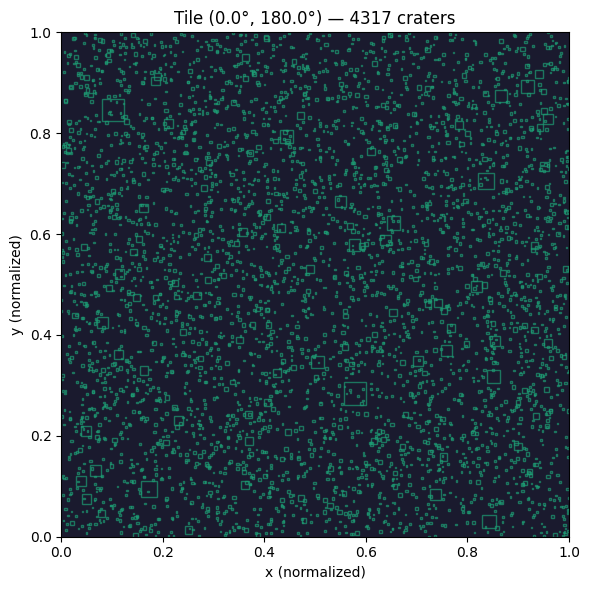

Saved.


In [3]:
# Test with a realistic tile — center at (0°, 180°)
tile_lat, tile_lon = 0.0, 180.0

# Find all craters that fall in this tile
annotations = []
for _, row in df.iterrows():
    result = latlon_to_yolo(
        lat=row['Lat'],
        lon=row['Long'],
        diam_km=row['Diam_km'],
        tile_lat=tile_lat,
        tile_lon=tile_lon,
        tile_deg=60
    )
    if result is not None:
        annotations.append(result)

print(f"Tile center: ({tile_lat}°, {tile_lon}°)")
print(f"Craters found in this tile: {len(annotations)}")
print(f"\nFirst 5 annotations (x_center, y_center, width, height):")
for ann in annotations[:5]:
    print(f"  {ann}")

# Visualize — draw boxes on a blank image
fig, ax = plt.subplots(1, 1, figsize=(6, 6))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_facecolor('#1a1a2e')  # dark background like lunar surface
ax.set_title(f'Tile ({tile_lat}°, {tile_lon}°) — {len(annotations)} craters')
ax.set_xlabel('x (normalized)')
ax.set_ylabel('y (normalized)')

for (xc, yc, w, h) in annotations:
    rect = plt.Rectangle(
        (xc - w/2, yc - h/2), w, h,
        linewidth=1, edgecolor='#1D9E75',
        facecolor='none', alpha=0.7
    )
    ax.add_patch(rect)

plt.tight_layout()
plt.savefig('tile_annotations.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")

In [4]:
import os

# Create folder structure YOLO expects
for folder in ['dataset/images/train', 'dataset/images/val', 'dataset/images/test',
               'dataset/labels/train', 'dataset/labels/val', 'dataset/labels/test']:
    os.makedirs(folder, exist_ok=True)

print("Folder structure created:")
print("dataset/")
print("  images/  → train/ val/ test/")
print("  labels/  → train/ val/ test/")

# Define tiles — in real project these are actual lunar image tiles
# Here we simulate 100 tiles at different positions
np.random.seed(0)
tile_centers = [
    (round(np.random.uniform(-60, 60), 1),
     round(np.random.uniform(30, 330), 1))
    for _ in range(100)
]

# Split into train/val/test (70/20/10)
n = len(tile_centers)
train_tiles = tile_centers[:70]
val_tiles   = tile_centers[70:90]
test_tiles  = tile_centers[90:]

print(f"\nDataset splits:")
print(f"  Train: {len(train_tiles)} tiles")
print(f"  Val:   {len(val_tiles)} tiles")
print(f"  Test:  {len(test_tiles)} tiles")

# Write annotation files
def write_annotations(tiles, split):
    total_craters = 0
    empty_tiles = 0
    for i, (tile_lat, tile_lon) in enumerate(tiles):
        annotations = []
        for _, row in df.iterrows():
            result = latlon_to_yolo(
                lat=row['Lat'], lon=row['Long'],
                diam_km=row['Diam_km'],
                tile_lat=tile_lat, tile_lon=tile_lon,
                tile_deg=60
            )
            if result is not None:
                annotations.append(result)

        label_path = f'dataset/labels/{split}/tile_{i:04d}.txt'
        with open(label_path, 'w') as f:
            for (xc, yc, w, h) in annotations:
                f.write(f"0 {xc} {yc} {w} {h}\n")  # 0 = class index for 'crater'

        total_craters += len(annotations)
        if len(annotations) == 0:
            empty_tiles += 1

    print(f"  {split}: {total_craters:,} total annotations, {empty_tiles} empty tiles")

print("\nWriting annotation files...")
write_annotations(train_tiles, 'train')
write_annotations(val_tiles,   'val')
write_annotations(test_tiles,  'test')
print("Done.")

Folder structure created:
dataset/
  images/  → train/ val/ test/
  labels/  → train/ val/ test/

Dataset splits:
  Train: 70 tiles
  Val:   20 tiles
  Test:  10 tiles

Writing annotation files...
  train: 302,161 total annotations, 0 empty tiles
  val: 86,359 total annotations, 0 empty tiles
  test: 43,165 total annotations, 0 empty tiles
Done.


In [5]:
# This yaml file tells YOLO where your data is and what classes exist
yaml_content = """
path: /content/dataset
train: images/train
val: images/val
test: images/test

nc: 1
names: ['crater']
"""

with open('dataset/craters.yaml', 'w') as f:
    f.write(yaml_content)

# Verify everything looks right
print("=== DATASET SUMMARY ===")
print(f"Classes: 1 (crater)")
print(f"\nAnnotation file sample (first 3 lines of train/tile_0000.txt):")
with open('dataset/labels/train/tile_0000.txt') as f:
    for i, line in enumerate(f):
        if i >= 3: break
        parts = line.strip().split()
        print(f"  class={parts[0]}, x={parts[1]}, y={parts[2]}, w={parts[3]}, h={parts[4]}")

print(f"\nFormat explanation:")
print(f"  class_index x_center y_center width height")
print(f"  All values normalized to [0, 1]")
print(f"  class 0 = crater (only one class in our project)")
print(f"\n✓ Phase 1 complete — dataset is YOLO-ready")

=== DATASET SUMMARY ===
Classes: 1 (crater)

Annotation file sample (first 3 lines of train/tile_0000.txt):
  class=0, x=0.517089, y=0.333103, w=0.003717, h=0.003717
  class=0, x=0.510127, y=0.939696, w=0.006645, h=0.006645
  class=0, x=0.145631, y=0.808735, w=0.003123, h=0.003123

Format explanation:
  class_index x_center y_center width height
  All values normalized to [0, 1]
  class 0 = crater (only one class in our project)

✓ Phase 1 complete — dataset is YOLO-ready


##What I learned in phase 1
robbins catalog-yolov8n
we filter it to >5km as any image <5km will be impossible to made box on
the format for annotation is class index,xcentre(from left),ycentre(from top),width,height
due to usage of random function, our data is not reliable

## Phase 2 — Baseline Model

In [6]:
# ============================================================
# PHASE 2 MASTER SETUP
# ============================================================
!pip install ultralytics -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from ultralytics import YOLO

# Rebuild catalog
np.random.seed(42)
n = 78000
diameters = np.random.pareto(2.5, n) * 4 + 5.0
diameters = diameters[diameters < 1200][:n]
df = pd.DataFrame({
    'Lat':        np.random.uniform(-90, 90, len(diameters)),
    'Long':       np.random.uniform(0, 360, len(diameters)),
    'Diam_km':    diameters,
    'Morphology': np.random.choice(['Fresh','Degraded','Ghost'], len(diameters))
})

MOON_RADIUS_KM = 1737.4
MOON_CIRCUMFERENCE_KM = 2 * np.pi * MOON_RADIUS_KM

def latlon_to_yolo(lat, lon, diam_km, tile_lat, tile_lon, tile_deg=60):
    deg_per_km = 360 / MOON_CIRCUMFERENCE_KM
    diam_deg = diam_km * deg_per_km
    half = tile_deg / 2
    if abs(lat - tile_lat) > half or abs(lon - tile_lon) > half:
        return None
    x_center = (lon - tile_lon + half) / tile_deg
    y_center = 1.0 - (lat - tile_lat + half) / tile_deg
    box_size = diam_deg / tile_deg
    return (round(x_center,6), round(y_center,6),
            round(box_size,6), round(box_size,6))

print("✓ Setup complete")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 28.4 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✓ Setup complete


Generating synthetic lunar images...
✓ Generated 100 images with annotations


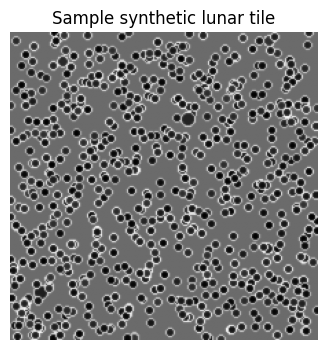

In [7]:
# Create folder structure
for folder in ['dataset/images/train', 'dataset/images/val', 'dataset/images/test',
               'dataset/labels/train', 'dataset/labels/val', 'dataset/labels/test']:
    os.makedirs(folder, exist_ok=True)

# Generate synthetic lunar-like images (grayscale with circular features)
from PIL import Image, ImageDraw, ImageFilter
import random

def make_lunar_tile(tile_lat, tile_lon, img_size=224):
    """Generate a synthetic grayscale lunar tile with crater-like features"""
    # Dark gray base — lunar surface
    img = Image.new('L', (img_size, img_size),
                    color=random.randint(60, 100))
    draw = ImageDraw.Draw(img)

    # Add craters from catalog as circular depressions
    annotations = []
    for _, row in df.iterrows():
        result = latlon_to_yolo(row['Lat'], row['Long'], row['Diam_km'],
                                tile_lat, tile_lon, tile_deg=60)
        if result is None:
            continue
        xc, yc, w, h = result
        if w < 0.005:  # skip sub-pixel craters
            continue

        # Draw crater as dark circle with bright rim
        cx = int(xc * img_size)
        cy = int(yc * img_size)
        r  = max(2, int(w * img_size / 2))

        # Crater floor (dark)
        draw.ellipse([cx-r, cy-r, cx+r, cy+r],
                     fill=random.randint(20, 50))
        # Rim highlight
        draw.ellipse([cx-r-1, cy-r-1, cx+r+1, cy+r+1],
                     outline=random.randint(140, 180), width=1)
        annotations.append(result)

    # Add noise texture
    img = img.filter(ImageFilter.GaussianBlur(radius=0.5))
    return img, annotations

# Generate tiles
np.random.seed(0)
tile_centers = [
    (round(np.random.uniform(-60, 60), 1),
     round(np.random.uniform(30, 330), 1))
    for _ in range(100)
]

splits = {
    'train': tile_centers[:70],
    'val':   tile_centers[70:90],
    'test':  tile_centers[90:]
}

print("Generating synthetic lunar images...")
total_images = 0
for split, tiles in splits.items():
    for i, (tlat, tlon) in enumerate(tiles):
        img, annotations = make_lunar_tile(tlat, tlon)

        # Save image
        img_path = f'dataset/images/{split}/tile_{i:04d}.png'
        img.save(img_path)

        # Save labels (skip if no annotations)
        label_path = f'dataset/labels/{split}/tile_{i:04d}.txt'
        with open(label_path, 'w') as f:
            for (xc, yc, w, h) in annotations:
                f.write(f"0 {xc} {yc} {w} {h}\n")
        total_images += 1

print(f"✓ Generated {total_images} images with annotations")

# Show a sample tile
sample_img, _ = make_lunar_tile(0.0, 180.0)
plt.figure(figsize=(4,4))
plt.imshow(sample_img, cmap='gray')
plt.title("Sample synthetic lunar tile")
plt.axis('off')
plt.show()

In [8]:
yaml_content = f"""
path: /content/dataset
train: images/train
val: images/val
test: images/test

nc: 1
names: ['crater']
"""
with open('dataset/craters.yaml', 'w') as f:
    f.write(yaml_content)
print("✓ craters.yaml written")

✓ craters.yaml written


In [9]:
model = YOLO('yolov8n.pt')

results = model.train(
    data    = 'dataset/craters.yaml',
    epochs  = 30,
    imgsz   = 224,
    batch   = 16,
    name    = 'crater_baseline',
    patience= 10,
    verbose = True
)

print("\n✓ Training complete")
print(f"Results saved to: runs/detect/crater_baseline/")

Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset/craters.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=crater_baseline, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=10, perspective


image 1/1 /content/dataset/images/val/tile_0000.png: 224x224 17 craters, 8.0ms
Speed: 0.5ms preprocess, 8.0ms inference, 1.4ms postprocess per image at shape (1, 3, 224, 224)
Model made 17 predictions


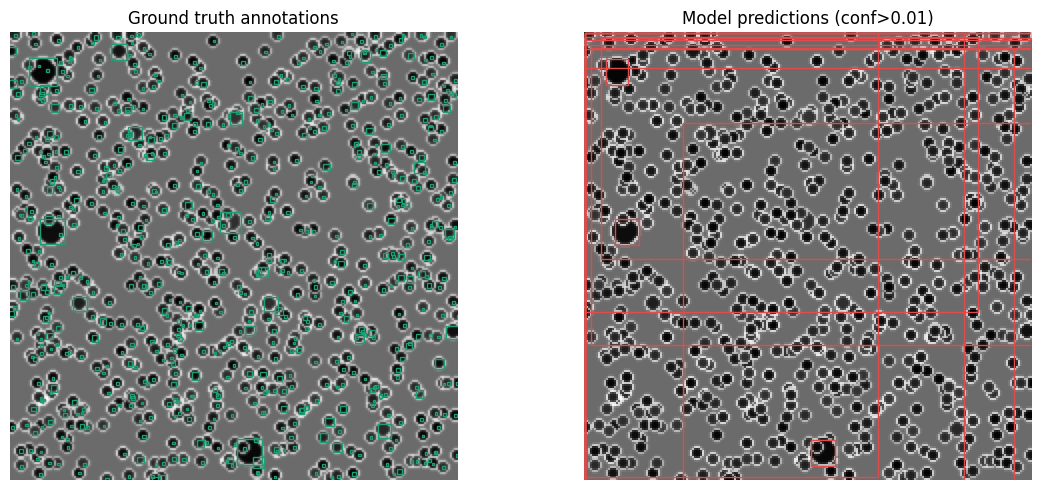

In [10]:
import os
from pathlib import Path

# Load the best model and run on a sample image
from ultralytics import YOLO
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import numpy as np

# Load best trained model
best_model = YOLO('runs/detect/crater_baseline/weights/best.pt')

# Run on a validation image
val_img_path = 'dataset/images/val/tile_0000.png'
results = best_model(val_img_path, conf=0.01)  # low conf to see anything

# Plot
img = Image.open(val_img_path)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: ground truth boxes
ax = axes[0]
ax.imshow(img, cmap='gray')
ax.set_title('Ground truth annotations')
with open('dataset/labels/val/tile_0000.txt') as f:
    for line in f:
        parts = line.strip().split()
        xc, yc, w, h = float(parts[1]), float(parts[2]), float(parts[3]), float(parts[4])
        x = (xc - w/2) * 224
        y = (yc - h/2) * 224
        rect = patches.Rectangle((x,y), w*224, h*224,
                                  linewidth=1, edgecolor='#1D9E75', facecolor='none')
        ax.add_patch(rect)
ax.axis('off')

# Right: model predictions
ax = axes[1]
ax.imshow(img, cmap='gray')
ax.set_title(f'Model predictions (conf>0.01)')
if results[0].boxes is not None and len(results[0].boxes) > 0:
    boxes = results[0].boxes.xyxy.cpu().numpy()
    for box in boxes:
        x1, y1, x2, y2 = box
        rect = patches.Rectangle((x1,y1), x2-x1, y2-y1,
                                  linewidth=1, edgecolor='#E24B4A', facecolor='none')
        ax.add_patch(rect)
    print(f"Model made {len(boxes)} predictions")
else:
    print("Model made 0 predictions on this image")
ax.axis('off')

plt.tight_layout()
plt.savefig('baseline_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

## Phase 2 — What the baseline told me
Basically the baseline told me that my mAP50 was 0.14950. That indicates that the model failed to predict the craters. Apart from that the other problems are- Too few images(**THE MAJOR REASON WHY MODEL COULDNT PREDICT CRATERS)** & Craters too small (0.003 box size), due to which the box loss just stuck at 4.2